In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [3]:
training_data = datasets.FashionMNIST(
    root="data",
    train = True,
    transform = ToTensor(),
    download = True
)

testing_data = datasets.FashionMNIST(
    root = "data",
    train= False,
    transform= ToTensor(),
    download = True
)



100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.82MB/s]


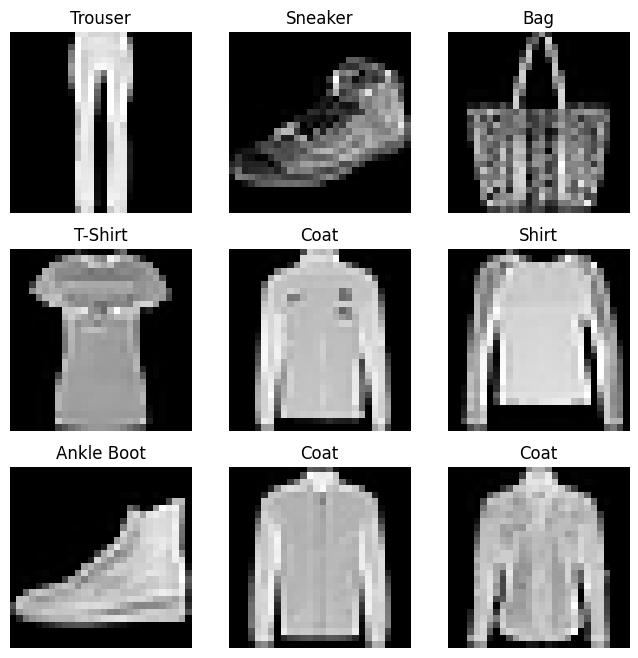

In [4]:
label_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

fig = plt.figure(figsize=(8,8))
cols,rows = 3,3

for i in range(1,cols*rows+1):
  idx = torch.randint(0,len(training_data),size=(1,)).item()
  img,label = training_data[idx]
  plt.subplot(rows,cols,i)
  plt.title(label_map[label])
  plt.axis('off')
  plt.imshow(img.squeeze(),cmap='gray')
plt.show()

# Creating Custom Dataset using Torch

In [5]:
import glob
import numpy as np
import pandas as pd
import torch
import cv2
from torch.utils.data import DataLoader

class CustomDataset(Dataset):
  def __init__(self):
    self.file_path = "/content/drive/MyDrive/Pytorch-Learning/Friends/"
    file_list = glob.glob(self.file_path + "*")
    self.Data = []
    for class_path in file_list:
      class_name = class_path.split("/")[-1]
      for img_path in glob.glob(class_path + "/*.jpg"):
        self.Data.append([img_path,class_name])
    self.class_label = {"Chandler":0,"Joey":1,"Ross":3}
    self.img_dim = (32,32)

  def __len__(self):
    return len(self.Data)

  def __getitem__(self,idx):
    img_path , class_name = self.Data[idx]
    img = cv2.imread(img_path)
    img = cv2.resize(img,self.img_dim)
    img_tensor = torch.tensor(img)
    img_tensor = img_tensor.permute(2,0,1)
    class_id = self.class_label[class_name]
    class_id = torch.tensor([class_id])

    return img_tensor,class_id



In [6]:
dataset = CustomDataset()
data_loader = DataLoader(dataset,batch_size=4,shuffle=True)

In [7]:
for imgs,labels in data_loader:
  print("Batch of images ",imgs.shape)
  print("Batch of labels ",labels.shape)

Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([4, 3, 32, 32])
Batch of labels  torch.Size([4, 1])
Batch of images  torch.Size([1, 3, 32, 32])
Batch of labels  torch.Size([1, 1])


# Transforms in Pytorch

In [8]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor,Lambda

In [9]:
ds = datasets.FashionMNIST(
    root='data',
    train = True,
    download = True,
    transform=ToTensor(),
    target_transform = Lambda(lambda y : torch.zeros(10,dtype=torch.float).scatter_(0,torch.tensor(y),value=1)),
)

In [10]:
train_loader = DataLoader(ds,batch_size=32,shuffle=True)

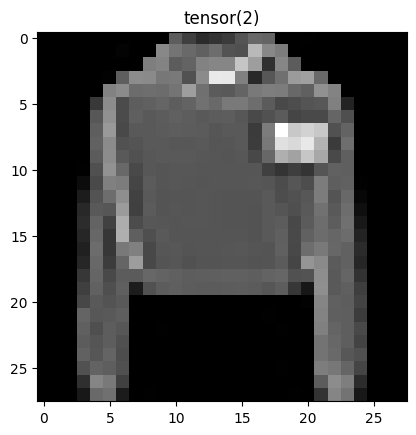

In [11]:
train_feature,train_labels = next(iter(train_loader))
img = train_feature[0].squeeze()
label = train_labels[0]
plt.imshow(img,cmap='gray')
plt.title(np.argmax(label))
plt.show()

# Building Neural Network

In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets , transforms

In [13]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,256),
        nn.ReLU(),
        nn.Linear(256,10),
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

In [14]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [15]:
X = torch.rand(1,28,28)
logits = model(X)
preds_prob = nn.Softmax(dim=1)(logits)
preds = preds_prob.argmax(1)
print("Prediction : ",preds)

Prediction :  tensor([9])


# Automatic Differentiation with torch.autograd

In [16]:
import torch

x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5,3,requires_grad=True)
b = torch.randn(3,requires_grad=True)

z = torch.matmul(x,w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)


In [17]:
loss.backward()
print(w.grad)
print(b.grad)


tensor([[0.1406, 0.0452, 0.3223],
        [0.1406, 0.0452, 0.3223],
        [0.1406, 0.0452, 0.3223],
        [0.1406, 0.0452, 0.3223],
        [0.1406, 0.0452, 0.3223]])
tensor([0.1406, 0.0452, 0.3223])


# Creating a Complete Neural Network

In [18]:
import torch
from torch.utils.data import DataLoader
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor

In [19]:
training_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)

testing_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

train_dataloader = DataLoader(training_data,batch_size=64)
test_dataloader = DataLoader(testing_data,batch_size=64)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.43MB/s]


In [20]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,32),
        nn.ReLU(),
        nn.Linear(32,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,512),
        nn.ReLU(),
        nn.Linear(512,10)
    )
  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

In [21]:
def train_loop(dataloader,model,loss_function,optimizer):
  model.train()
  for batch,(X,y) in enumerate(dataloader):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_function(pred,y)

    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss = loss.item()
      print(f"loss: {loss:>7f}")


def test_loop(dataloader,model,loss_function,optimizer):
  model.eval()
  num_batch = len(dataloader)
  test_loss = 0

  with torch.no_grad():
    for X,y in dataloader:
      pred = model(X)
      test_loss = test_loss + loss_function(pred,y).item()
  test_loss = test_loss / num_batch
  print("Test loss : ",test_loss)


In [22]:
model = NeuralNetwork()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)
epochs = 50
for epoch in range(epochs):
  print(f"epoch : {epoch+1}")
  train_loop(train_dataloader,model,loss_function,optimizer)
  test_loop(test_dataloader,model,loss_function,optimizer)
print("Done")


epoch : 1
loss: 2.306990
loss: 2.306466
loss: 2.294275
loss: 2.297488
loss: 2.304355
loss: 2.304405
loss: 2.301752
loss: 2.308307
loss: 2.301712
loss: 2.291958
Test loss :  2.3005937573256765
epoch : 2
loss: 2.303749
loss: 2.303709
loss: 2.294365
loss: 2.296389
loss: 2.303733
loss: 2.303184
loss: 2.298542
loss: 2.307155
loss: 2.300636
loss: 2.290480
Test loss :  2.2987055079952166
epoch : 3
loss: 2.300689
loss: 2.301058
loss: 2.294165
loss: 2.294980
loss: 2.302881
loss: 2.301764
loss: 2.295407
loss: 2.305716
loss: 2.299175
loss: 2.288674
Test loss :  2.296557393043664
epoch : 4
loss: 2.297433
loss: 2.298130
loss: 2.293523
loss: 2.293046
loss: 2.301499
loss: 2.299898
loss: 2.291883
loss: 2.303742
loss: 2.296975
loss: 2.286234
Test loss :  2.2937944846548093
epoch : 5
loss: 2.293622
loss: 2.294537
loss: 2.292336
loss: 2.290164
loss: 2.299225
loss: 2.297312
loss: 2.287427
loss: 2.300856
loss: 2.293680
loss: 2.282574
Test loss :  2.289886681137571
epoch : 6
loss: 2.288642
loss: 2.289692
lo

KeyboardInterrupt: 

# Complete House Price Prediction Pipeline

In [60]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.5 MB/s eta 0:00:00


In [61]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from torch.utils.data import DataLoader
from torch import nn
from torchmetrics import R2Score

train_data = pd.read_csv("/content/sample_data/california_housing_train.csv")
test_data = pd.read_csv("/content/sample_data/california_housing_test.csv")

labels_train = train_data['median_house_value']
labels_test = test_data['median_house_value']

X_train = train_data.drop(columns=['median_house_value'])
X_test = test_data.drop(columns=['median_house_value'])

class HousePriceDataset(Dataset):
  def __init__(self,X,y): # used for initalizing values
    self.X = X
    self.y = y.values.reshape(-1,1)

  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx): # used for applying any kind of transformation
    feature = torch.tensor(self.X[idx],dtype=torch.float)
    label = torch.tensor(self.y[idx],dtype=torch.float)
    return feature,label




<Figure size 1000x1000 with 0 Axes>

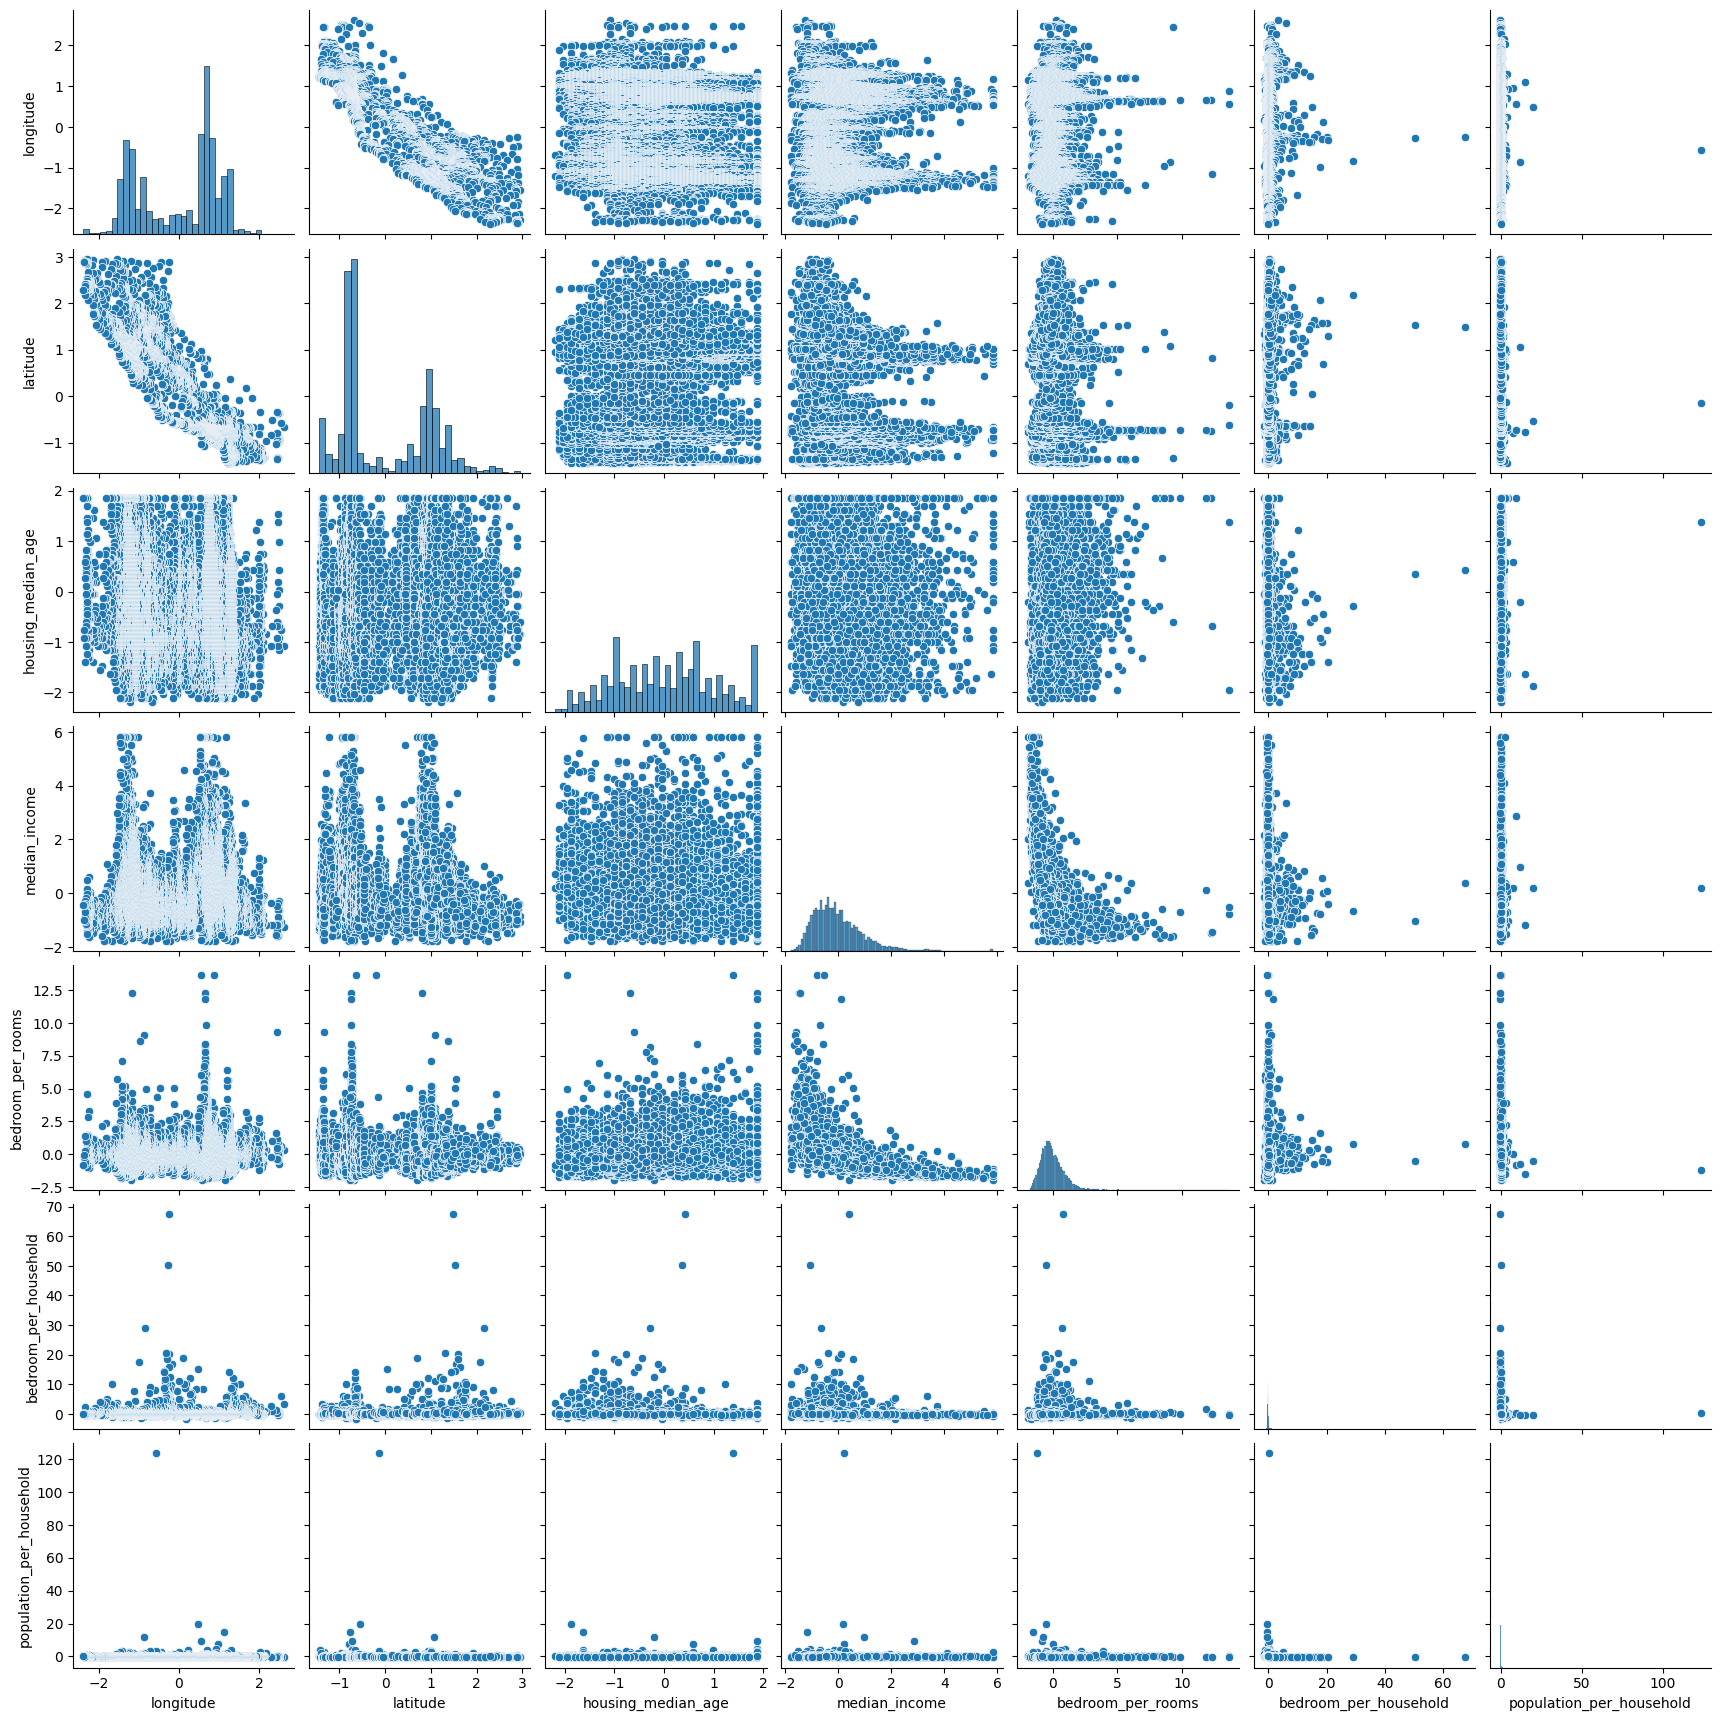

In [62]:
Scaler = StandardScaler()
X_train["bedroom_per_rooms"] = X_train["total_bedrooms"] / X_train["total_rooms"]
X_train["bedroom_per_household"] = X_train["total_bedrooms"] / X_train['households']
X_train["population_per_household"] = X_train["population"] / X_train['households']
# X_train["rooms_per_population"] = X_train["total_rooms"] / X_train["population"]

X_train = X_train.drop(columns=["total_bedrooms","total_rooms","households","population"])


X_test["bedroom_per_rooms"] = X_test["total_bedrooms"] / X_test["total_rooms"]
X_test["bedroom_per_household"] = X_test["total_bedrooms"] / X_test['households']
X_test["population_per_household"] = X_test["population"] / X_test['households']
# X_test["rooms_per_population"] = X_test["total_rooms"] / X_test["population"]

X_test = X_test.drop(columns=["total_bedrooms","total_rooms","households","population"])


X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)
view_df = pd.DataFrame(X_train_scaled,columns=X_train.columns)

plt.figure(figsize=(10,10))
sns.pairplot(data=view_df)
plt.show()



In [65]:
train_dataset = HousePriceDataset(X_train_scaled,labels_train)
test_dataset = HousePriceDataset(X_test_scaled,labels_test)


train_loader = DataLoader(train_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

X,y = next(iter(train_loader))
print(X.shape)
print(y.shape)

torch.Size([32, 7])
torch.Size([32, 1])


In [66]:
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(7,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,256),
        nn.ReLU(),
        nn.Linear(256,1)
    )

  def forward(self,x):
    pred = self.linear_relu_stack(x)
    return pred

In [67]:
def train_loop(model,optimizer,loss_func,dataloader):
  model.train()
  training_loss = 0.0
  for X,y in dataloader:
    optimizer.zero_grad() # reset gradients

    pred = model(X)
    loss = loss_func(pred,y)

    loss.backward() # calculate new gradients
    optimizer.step() # update values

    training_loss = training_loss + loss.item()
    avg_training_loss = training_loss / len(dataloader)

  return avg_training_loss

def test_loop(model,optimizer,loss_func,dataloader):
  test_loss = 0
  model.eval()
  with torch.no_grad():
    for X,y in dataloader:
      preds = model(X)
      loss = loss_func(preds,y)
      test_loss = test_loss + loss.item()
      avg_test_loss = test_loss / len(dataloader)
  return avg_test_loss



In [71]:
model = NeuralNet()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
loss_function = torch.nn.L1Loss()
r2_metric = R2Score()
loss_dict = {}

for epoch in range(200):
    train_loss = train_loop(
        model,
        optimizer=optimizer,
        loss_func=loss_function,
        dataloader=train_loader
    )

    model.eval()
    r2_metric.reset()

    with torch.no_grad():
        for X, y in test_loader:
            preds = model(X)
            r2_metric.update(preds, y)

    r2 = r2_metric.compute()

    print(f"Epoch {epoch+1} | Train loss: {train_loss:.4f} | Test R²: {r2:.4f}")



Epoch 1 | Train loss: 150067.2892 | Test R²: -3.6164
Epoch 2 | Train loss: 80210.7580 | Test R²: 0.1184
Epoch 3 | Train loss: 61276.5378 | Test R²: 0.4099
Epoch 4 | Train loss: 55285.8495 | Test R²: 0.4797
Epoch 5 | Train loss: 52430.1058 | Test R²: 0.5129
Epoch 6 | Train loss: 50771.3594 | Test R²: 0.5394
Epoch 7 | Train loss: 49710.1712 | Test R²: 0.5643
Epoch 8 | Train loss: 48911.1402 | Test R²: 0.5795
Epoch 9 | Train loss: 48321.1413 | Test R²: 0.5940
Epoch 10 | Train loss: 47846.9495 | Test R²: 0.6042
Epoch 11 | Train loss: 47477.1006 | Test R²: 0.6128
Epoch 12 | Train loss: 47158.3888 | Test R²: 0.6197
Epoch 13 | Train loss: 46881.4496 | Test R²: 0.6262
Epoch 14 | Train loss: 46671.6477 | Test R²: 0.6307
Epoch 15 | Train loss: 46458.7504 | Test R²: 0.6360
Epoch 16 | Train loss: 46240.1722 | Test R²: 0.6402
Epoch 17 | Train loss: 46063.5695 | Test R²: 0.6437
Epoch 18 | Train loss: 45881.5760 | Test R²: 0.6468
Epoch 19 | Train loss: 45709.0427 | Test R²: 0.6494
Epoch 20 | Train lo